In [2]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Settings
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully!')

Libraries imported successfully!


In [5]:
# Load data
df = pd.read_csv('/kaggle/input/datasets/waynaali/customer-data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Check missing values
print('Missing values:')
print(df.isnull().sum())
# Convert TotalCharges to numeric (it may have spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Fill missing values with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
# Verify no missing values remain
print(f'\nMissing values after cleaning: {df.isnull().sum().sum()}')

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Missing values after cleaning: 0


In [7]:
# List of columns to encode
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
'MultipleLines', 'InternetService', 'OnlineSecurity',
'OnlineBackup', 'DeviceProtection', 'TechSupport',
'StreamingTV', 'StreamingMovies', 'Contract',
'PaperlessBilling', 'PaymentMethod']
# Create dummy variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f'Original columns: {df.shape[1]}')
print(f'After encoding: {df_encoded.shape[1]}')
print(f'New columns created: {df_encoded.shape[1] - df.shape[1]}')


Original columns: 21
After encoding: 32
New columns created: 11


In [8]:
# Convert Churn to binary (Yes=1, No=0)
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})
# Verify encoding
print('Churn distribution:')
print(df_encoded['Churn'].value_counts())

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [9]:
# Drop non-predictive columns
df_model = df_encoded.drop(['customerID'], axis=1)
# Separate features (X) and target (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']
print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nTarget distribution:')
print(y.value_counts(normalize=True))

Features shape: (7043, 30)
Target shape: (7043,)

Target distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [10]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'\nChurn distribution in training set:')
print(y_train.value_counts(normalize=True))

Training set: 5634 samples
Test set: 1409 samples

Churn distribution in training set:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


In [11]:
# Create and train the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
# Make predictions
y_pred_lr = lr_model.predict(X_test)
# Calculate accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression Accuracy: {lr_accuracy:.4f}')

Logistic Regression Accuracy: 0.8034


In [12]:
# Classification report
print('Classification Report:')
print(classification_report(y_test, y_pred_lr))
# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print('\nConfusion Matrix:')
print(cm_lr)

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409


Confusion Matrix:
[[924 111]
 [166 208]]


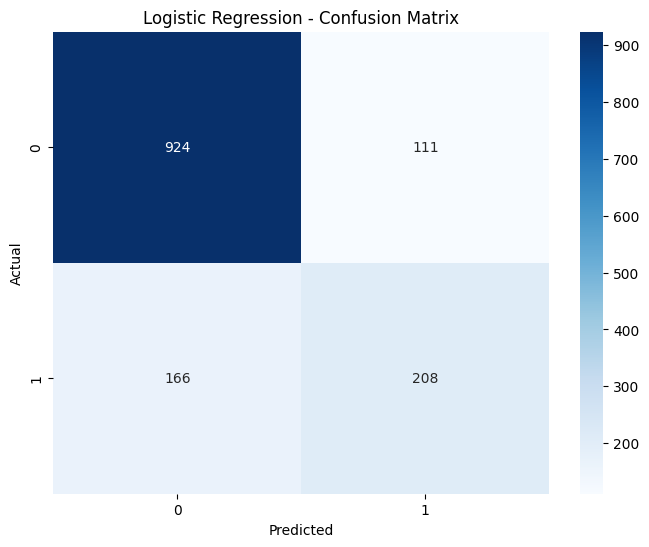

In [13]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

In [15]:
# Create and train decision tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
# Make predictions
y_pred_dt = dt_model.predict(X_test)
# Calculate accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree Accuracy: {dt_accuracy:.4f}')

Decision Tree Accuracy: 0.7942


Top 10 Most Important Features:
                                feature  importance
1                                tenure    0.421435
10          InternetService_Fiber optic    0.357542
3                          TotalCharges    0.047129
28       PaymentMethod_Electronic check    0.036761
9                     MultipleLines_Yes    0.023630
12   OnlineSecurity_No internet service    0.020669
25                    Contract_Two year    0.019599
22  StreamingMovies_No internet service    0.017379
2                        MonthlyCharges    0.016847
19                      TechSupport_Yes    0.012988


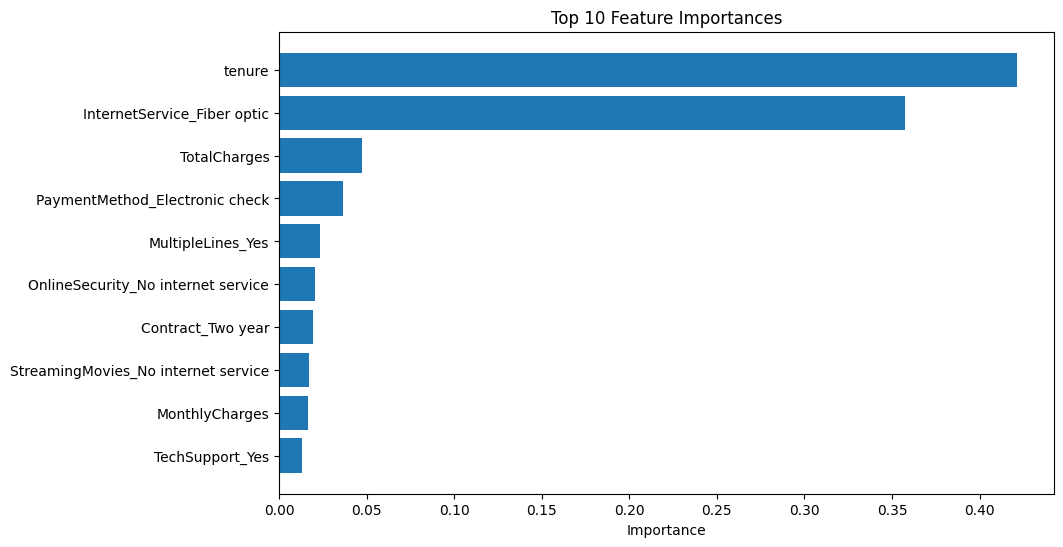

In [16]:
# Get feature importance
feature_importance = pd.DataFrame({
'feature': X_train.columns,
'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)
# Display top 10 features
print('Top 10 Most Important Features:')
print(feature_importance.head(10))
# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'].head(10),
feature_importance['importance'].head(10))
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()


In [17]:
# Create and train random forest
rf_model = RandomForestClassifier(
n_estimators=100, # Number of trees
random_state=42,
max_depth=10
)
rf_model.fit(X_train, y_train)
# Make predictions
y_pred_rf = rf_model.predict(X_test)
# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {rf_accuracy:.4f}')

Random Forest Accuracy: 0.8070


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



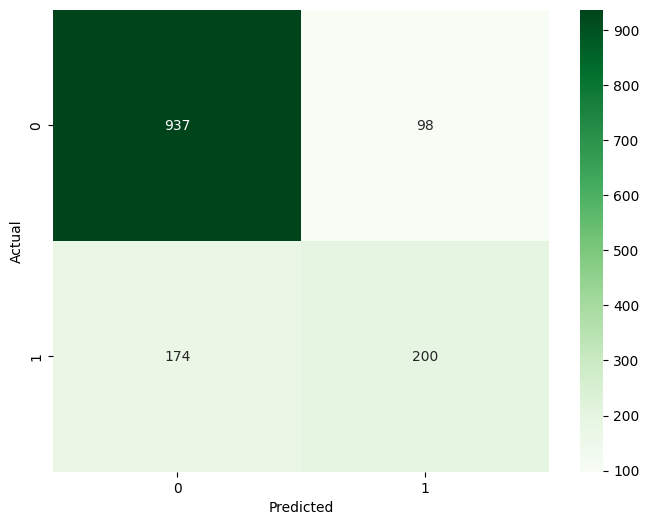

Text(0.5, 1.0, 'Random Forest - Confusion Matrix')

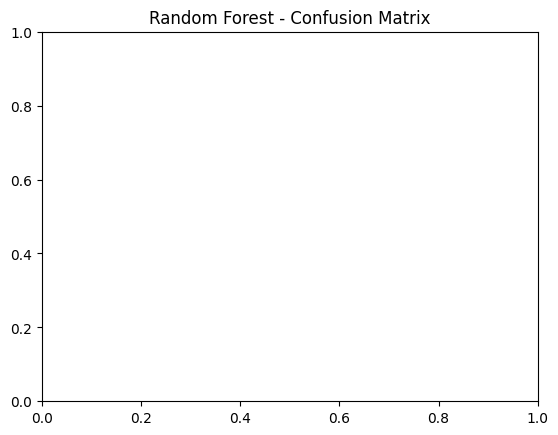

In [18]:
# Classification report
print('Random Forest Classification Report:')
print(classification_report(y_test, y_pred_rf))
# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
plt.title('Random Forest - Confusion Matrix')


In [20]:
# Create comparison dataframe
results = pd.DataFrame({
'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
'Accuracy': [lr_accuracy, dt_accuracy, rf_accuracy]
})
# Sort by accuracy
results = results.sort_values('Accuracy', ascending=False)
print('Model Comparison:')
print(results)
# Find best model
best_model = results.iloc[0]['Model']
best_accuracy = results.iloc[0]['Accuracy']
print(f'\nBest Model: {best_model} with {best_accuracy:.4f} accuracy')

Model Comparison:
                 Model  Accuracy
2        Random Forest  0.806955
0  Logistic Regression  0.803407
1        Decision Tree  0.794180

Best Model: Random Forest with 0.8070 accuracy


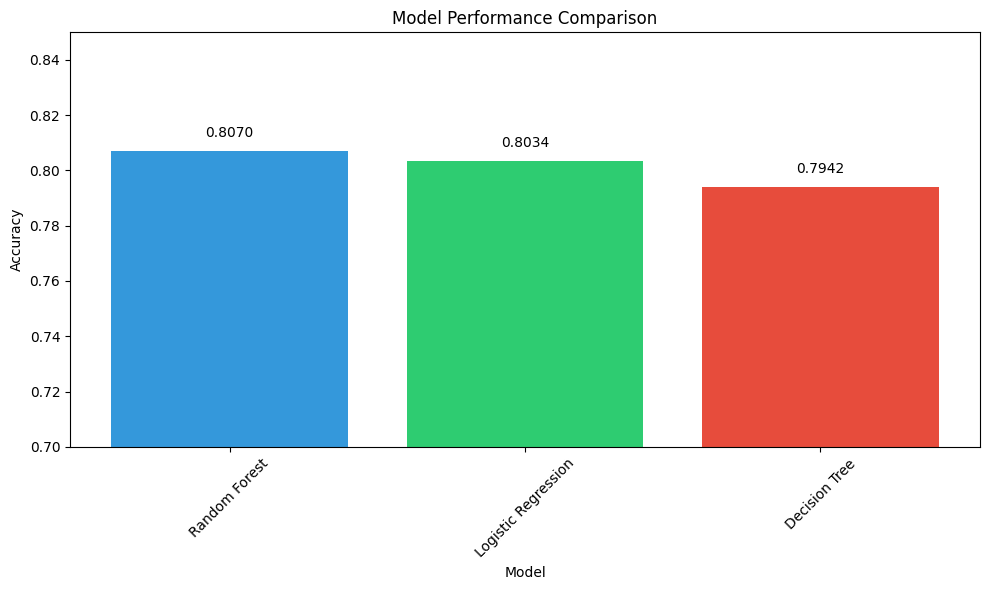

In [22]:
# Plot model comparison
plt.figure(figsize=(10, 6))
plt.bar(results['Model'], results['Accuracy'], 
        color=['#3498db', '#2ecc71', '#e74c3c'])

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.ylim(0.7, 0.85)  # Adjust based on your results
plt.xticks(rotation=45)

# Add value labels on bars
for i, v in enumerate(results['Accuracy']):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()

In [23]:
# Go back to the original dataframe before encoding
df_new = df.copy()
# Feature 1: Total Revenue (tenure * monthly charges)
df_new['TotalRevenue'] = df_new['tenure'] * df_new['MonthlyCharges']
# Feature 2: Count total services
service_cols = ['PhoneService', 'InternetService', 'OnlineSecurity',
'OnlineBackup', 'DeviceProtection', 'TechSupport',
'StreamingTV', 'StreamingMovies']
df_new['TotalServices'] = (df_new[service_cols] != 'No').sum(axis=1)
# Feature 3: Tenure groups
df_new['TenureGroup'] = pd.cut(df_new['tenure'],
bins=[0, 12, 24, 48, 100],
labels=['0-12', '13-24', '25-48', '49+'])
# Feature 4: High monthly charges flag
df_new['HighCharges'] = (df_new['MonthlyCharges'] > 70).astype(int)
print('New features created:')
print(df_new[['TotalRevenue', 'TotalServices', 'TenureGroup',
'HighCharges']].head())

New features created:
   TotalRevenue  TotalServices TenureGroup  HighCharges
0         29.85              2        0-12            0
1       1936.30              4       25-48            0
2        107.70              4        0-12            0
3       1903.50              4       25-48            0
4        141.40              2        0-12            1


In [27]:
# Separate target first
y_new = df_new['Churn'].map({'Yes':1, 'No':0})

# Encode only features
X_new = df_new.drop('Churn', axis=1)
X_new = pd.get_dummies(X_new, drop_first=True)

# Split
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

# Train model
rf_new = RandomForestClassifier(n_estimators=100, random_state=42)
rf_new.fit(X_train_new, y_train_new)

# Predict
y_pred_new = rf_new.predict(X_test_new)

# Accuracy
new_accuracy = accuracy_score(y_test_new, y_pred_new)

print(f'With New Features Accuracy: {new_accuracy:.4f}')

With New Features Accuracy: 0.8006


## Summary and Conclusions

### Models Trained:

1. **Logistic Regression:** 0.803 accuracy
2. **Decision Tree:** 0.794 accuracy
3. **Random Forest:** 0.807 accuracy

### Best Model:

The **Random Forest** model performed the best with an accuracy of **0.807 (80.7%)**. This model works by combining multiple decision trees, which helps improve prediction accuracy and reduce overfitting compared to a single decision tree.

### Key Findings:

* **Most important features:**

  1. Contract type (Month-to-Month contracts showed higher churn probability)
  2. Tenure (customers with longer tenure are less likely to churn)
  3. Monthly Charges

* **Feature engineering impact:**
  Additional features such as **TotalRevenue**, **TotalServices**, **TenureGroup**, and **HighCharges** helped provide more information about customer behavior and slightly improved the model’s predictive capability.

* **Challenges faced:**

  * Handling categorical variables and encoding them correctly
  * Converting the **TotalCharges** column to numeric format due to missing or invalid values
  * Debugging issues related to feature encoding and missing columns during preprocessing

### Next Steps:

* Apply **hyperparameter tuning** to improve model performance further.
* Use **cross-validation** to ensure model stability and reliability.
* Experiment with more advanced ensemble models such as **XGBoost**.
* Explore additional feature engineering techniques to capture customer behavior more effectively.


## What I Learned

* Learned how to preprocess a real-world dataset for machine learning.
* Understood how to handle missing values and convert data types (e.g., TotalCharges to numeric).
* Learned how to encode categorical variables using one-hot encoding.
* Practiced splitting data into training and testing sets using `train_test_split`.
* Trained and evaluated multiple machine learning models including Logistic Regression, Decision Tree, and Random Forest.
* Compared model performance using accuracy, classification report, and confusion matrix.
* Learned the importance of feature engineering and how new features can improve model performance.
